# Medium Subset Mad

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.deserialize_experiment_configuration import (
    deserialize_experiment_configuration,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_parameters,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

%load_ext autoreload
%autoreload 2

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:178: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:183: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [3]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [4]:
from social_groups.analysis.definitions import defs

medium_mad: pl.DataFrame = defs().load_asset_value("final_medium_subset_mad")

big_homo_mad: pl.DataFrame = defs().load_asset_value(
    ["report", "final_mad_baseline", "homogeneous_mad_big_subset_result"]
)

big_size_hetero_mad: pl.DataFrame = defs().load_asset_value(
    ["report", "final_mad_baseline", "size_heterogeneous_mad_big_subset_result"]
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-06-17 08:31:03 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_medium_subset_mad.parquet using PolarsParquetIOManager...
2026-06-17 08:31:04 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/homogeneous_mad_big_subset_result.parquet using PolarsParquetIOManager...
2026-06-17 08:31:04 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/

In [5]:
medium_mad = apply_parsing_and_group_decision(medium_mad, parser, comparer, group_reply)

In [6]:
medium_mad.head()

shape: (5, 33)
┌────────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ id     ┆ run_id ┆ message_id ┆ question_i ┆ … ┆ ___parsed_ ┆ ___parsed_ ┆ ___parsed_ ┆ is_correc │
│ ---    ┆ ---    ┆ s          ┆ d          ┆   ┆ individual ┆ combined_a ┆ combined_a ┆ t         │
│ i64    ┆ i64    ┆ ---        ┆ ---        ┆   ┆ _answers_a ┆ nswers_bef ┆ nswers_aft ┆ ---       │
│        ┆        ┆ list[i64]  ┆ i64        ┆   ┆ …          ┆ …          ┆ …          ┆ bool      │
│        ┆        ┆            ┆            ┆   ┆ ---        ┆ ---        ┆ ---        ┆           │
│        ┆        ┆            ┆            ┆   ┆ list[str]  ┆ str        ┆ str        ┆           │
╞════════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 187010 ┆ 372    ┆ []         ┆ 274        ┆ … ┆ ["J"]      ┆ J          ┆ J          ┆ true      │
│ 187011 ┆ 372    ┆ []         ┆ 277        ┆ … ┆ ["C"]      ┆ C          ┆ C          ┆ true      │
│ 187012 ┆ 372    ┆ []         ┆ 275        ┆ … ┆ ["C"]      ┆ C          ┆ C          ┆ false     │
│ 187013 ┆ 372    ┆ []         ┆ 276        ┆ … ┆ ["B"]      ┆ B          ┆ B          ┆ true      │
│ 187014 ┆ 372    ┆ []         ┆ 245        ┆ … ┆ ["A"]      ┆ A          ┆ A          ┆ true      │
└────────┴────────┴────────────┴────────────┴───┴────────────┴────────────┴────────────┴───────────┘

In [7]:
NUM_ROUNDS = (
    medium_mad.with_columns(
        deserialize_experiment_configuration(pl.col("experiment_configuration_json"))
        .struct.field("strategy")
        .struct.field("configuration")
        .struct.field("number_of_rounds")
        .alias("number_of_rounds")
    )["number_of_rounds"]
    .unique()
    .item()
)

In [41]:
from social_groups.analysis.polars_transformations.pareto_front import add_pareto_flag
medium_mad_result = (
    medium_mad.group_by("model_family", plc.group_constellation)
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
        pl.col("model_names").unique().item(),
        (
            pl.col("___parsed_individual_answers_after___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_after___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_after"),
        (
            pl.col("___parsed_individual_answers_before___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_before___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_before"),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        pl.col("group_constellation").str.split("").list.sort().alias("sizes"),
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2 * NUM_ROUNDS)
        .list.sum(),
    )
    .with_columns(
        group_size=pl.col("group_constellation").str.len_chars(),
        is_homogeneous=pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.len()
        == 1,
    )
)

medium_mad_result = add_pareto_flag(medium_mad_result, [

        "model_family",

        "group_size",

        "is_homogeneous",

    ], "call_cost_heuristic", "accuracy", flag_name="is_pareto" )

In [29]:
interesting = ["group_constellation", "model_family", "accuracy"]

comparison_medium_big = (
    medium_mad_result.select(interesting + ["group_size", "is_homogeneous"])
    .join(
        big_homo_mad.select(interesting),
        on=["group_constellation", "model_family"],
        suffix="_big_homo",
        how="left",
    )
    .join(
        big_size_hetero_mad.select(interesting),
        on=["group_constellation", "model_family"],
        suffix="_big_hetero",
        how="left",
    )
    .with_columns(
        pl.coalesce(["accuracy_big_homo", "accuracy_big_hetero"]).alias("accuracy_big")
    )
    .drop(["accuracy_big_homo", "accuracy_big_hetero"])
    .rename({"accuracy": "accuracy_medium"})
    .with_columns(
        (pl.col("accuracy_medium") - pl.col("accuracy_big")).alias("accuracy_diff")
    )
)

comparison_medium_big

group_constellation,model_family,accuracy_medium,group_size,is_homogeneous,accuracy_big,accuracy_diff
str,str,f64,u32,bool,f64,f64
"""HHHH""","""Qwen3""",0.796667,4,true,null,null
"""HH""","""Qwen3""",0.783333,2,true,0.753,0.030333
"""HLM""","""Qwen3.5""",0.773333,3,false,0.732,0.041333
"""H""","""Qwen3.5""",0.77,1,true,null,null
"""HHH""","""Qwen3""",0.763333,3,true,0.766,-0.002667
…,…,…,…,…,…,…
"""LLLL""","""Qwen3""",0.263333,4,true,null,null
"""LLL""","""Qwen3""",0.263333,3,true,0.304,-0.040667
"""L""","""Qwen3""",0.26,1,true,null,null


In [27]:
labels = {
    "accuracy_medium": "Accuracy (Large Subset)",
    "accuracy_big": "Accuracy (Medium Subset)",
    "accuracy_diff": "Difference (Big -> Med.)",
}

corr_table = (
    comparison_medium_big.drop_nulls()
    .select(pl.selectors.numeric())
    .select([k for k, v in labels.items()])
    .corr()
    .rename(labels)
    .select(pl.selectors.numeric().round(3))
)

corr_table = corr_table.to_pandas()

corr_table.index = corr_table.columns

corr_table

register_materialization(
    "accuracy_correlation_medium_and_big_subset",
    corr_table,
    "Correlation of Accuracy Metrics between Large and Medium Subset of MMLUPro",
    force=True,
)

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/accuracy_correlation_medium_and_big_subset.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


In [11]:
summary = (
    comparison_medium_big.drop_nulls()
    .group_by("model_family")
    .agg(
        pl.col("accuracy_diff").mean().alias("Mean"),
        pl.col("accuracy_diff").std().alias("SD"),
    )
    .with_columns(
        pl.format(
            "{} ± {}",
            pl.col("Mean").round(3).cast(pl.String),
            pl.col("SD").round(3).cast(pl.String),
        ).alias(
            "Accuracy Difference (Big -> Medium)",
        )
    )
    .select(
        pl.col("model_family").alias("Model Family"),
        "Accuracy Difference (Big -> Medium)",
    )
    .sort("Model Family")
)

register_materialization(
    "accuracy_difference_from_big_to_medium_subset",
    summary,
    "Accuracy Difference between Large and Medium Subset of MMLUPro by families",
    force=True,
)

summary

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/accuracy_difference_from_big_to_medium_subset.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Model Family,Accuracy Difference (Big -> Medium)
str,str
"""Ministral""","""-0.005 ± 0.019"""
"""Qwen3""","""0.02 ± 0.031"""
"""Qwen3.5""","""0.033 ± 0.019"""


In [81]:
medium_mad_result.filter(pl.col("call_cost_heuristic").is_between(250, 300), model_family="Qwen3")

model_family,group_constellation,len,accuracy,used_input_tokens,used_output_tokens,model_names,amount_parsing_errors_after,amount_parsing_errors_before,sizes,call_cost_heuristic,group_size,is_homogeneous,is_pareto
str,str,u32,f64,f64,f64,list[str],f64,f64,list[str],f64,u32,bool,bool
"""Qwen3""","""HHHL""",300,0.68,59559.943333,12554.57,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", … ""Qwen/Qwen3-0.6B""]",0.0375,0.0975,"[""H"", ""H"", … ""L""]",255.6,4,false,false
"""Qwen3""","""HHHM""",300,0.763333,57244.303333,11759.53,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", … ""Qwen/Qwen3-4B""]",0.026667,0.0825,"[""H"", ""H"", … ""M""]",276.0,4,false,true
"""Qwen3""","""HHH""",300,0.763333,34659.043333,8623.216667,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.034444,0.062222,"[""H"", ""H"", ""H""]",252.0,3,true,true


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/medium_subset_pareto_friend_by_group_size.png


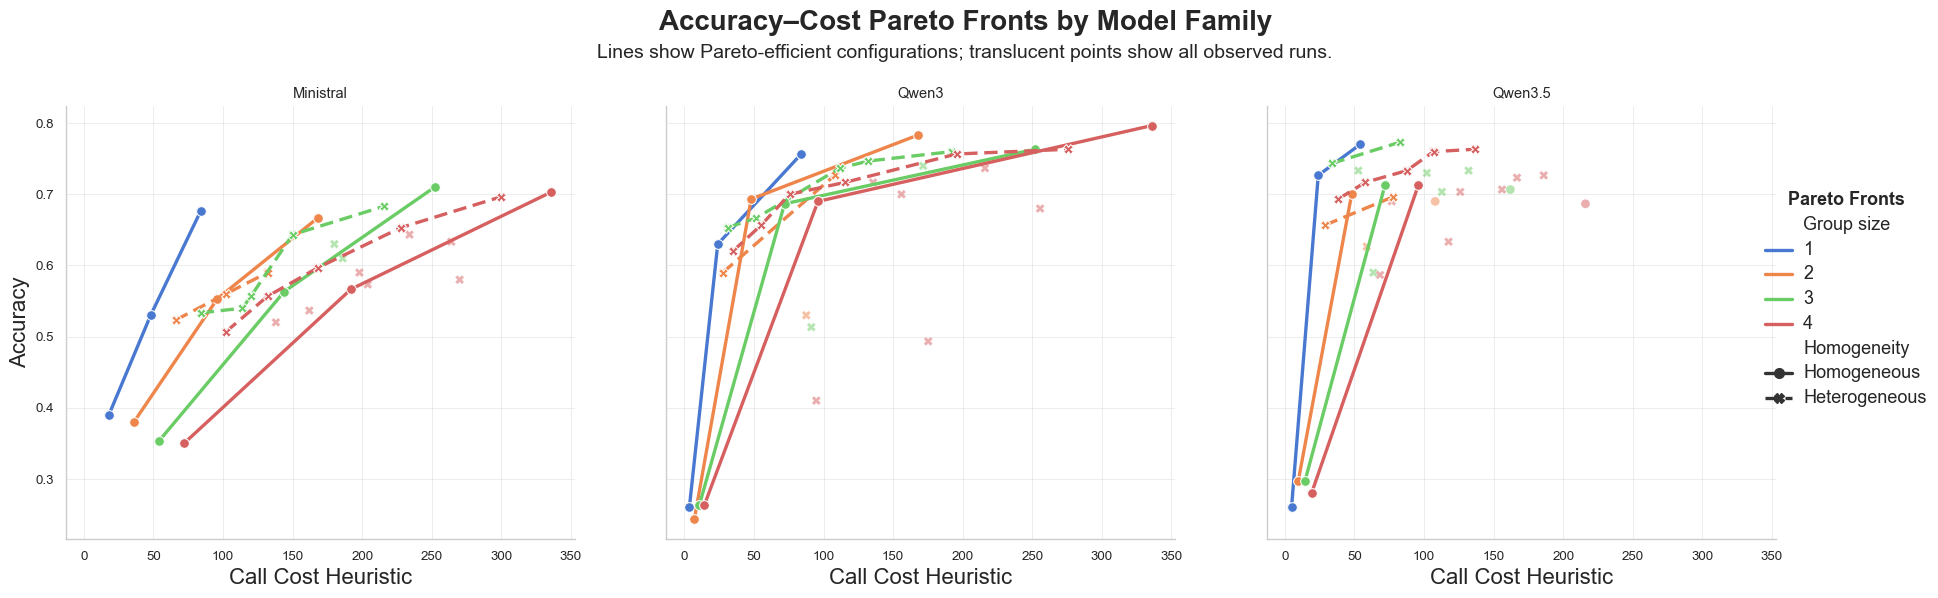

In [83]:
df = medium_mad_result.to_pandas()


sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="muted",
    font_scale=1.1,
)




def pareto_front(group, x="call_cost_heuristic", y="accuracy"):
    g = group.dropna(subset=[x, y]).sort_values([x, y], ascending=[True, False])

    best_acc = -float("inf")
    rows = []

    for _, row in g.iterrows():
        if row[y] > best_acc:
            rows.append(row)
            best_acc = row[y]

    return pd.DataFrame(rows)


plot_df = df.copy()

plot_df["Homogeneity"] = plot_df["is_homogeneous"].map(
    {
        True: "Homogeneous",
        False: "Heterogeneous",
    }
)

plot_df["Group size"] = plot_df["group_size"].astype(str)
plot_df["Model family"] = plot_df["model_family"]

fronts = (
    plot_df.groupby(["Model family", "Group size", "Homogeneity"], group_keys=False)[
        [
            "Model family",
            "Group size",
            "Homogeneity",
            "call_cost_heuristic",
            "accuracy",
            "group_constellation",
        ]
    ]
    .apply(pareto_front)
    .reset_index(drop=True)
)

group_size_order = sorted(plot_df["Group size"].unique(), key=int)
palette = dict(zip(group_size_order, sns.color_palette("muted", len(group_size_order))))

homogeneity_order = ["Homogeneous", "Heterogeneous"]
markers = {
    "Homogeneous": "o",
    "Heterogeneous": "X",
}

g = sns.relplot(
    data=fronts,
    x="call_cost_heuristic",
    y="accuracy",
    col="Model family",
    hue="Group size",
    style="Homogeneity",
    kind="line",
    style_order=homogeneity_order,
    markers=markers,
    dashes={
        "Homogeneous": "",
        "Heterogeneous": (4, 2),
    },
    linewidth=2.4,
    markersize=7,
    facet_kws={"sharex": True, "sharey": True},
    height=6,
    hue_order=group_size_order,
    palette=palette,
)

# Add all raw observations behind the Pareto fronts
for ax, model_family in zip(g.axes.flat, g.col_names):
    subset = plot_df[plot_df["Model family"] == model_family]

    sns.scatterplot(
        data=subset,
        x="call_cost_heuristic",
        y="accuracy",
        hue="Group size",
        style="Homogeneity",
        alpha=0.5,
        style_order=homogeneity_order,
        markers=markers,
        s=42,
        linewidth=0.3,
        edgecolor="white",
        legend=False,
        ax=ax,
        hue_order=group_size_order,
        palette=palette,
    )

    # Keep Pareto lines visually on top
    ax.set_title(model_family, fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("Call Cost Heuristic", fontsize=16)
    ax.set_ylabel("Accuracy", fontsize=16)
    ax.grid(True, linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Redraw Pareto lines on top of scatter
for ax in g.axes.flat:
    for line in ax.lines:
        line.set_zorder(10)
    for collection in ax.collections:
        collection.set_zorder(2)


# for ax in g.axes.flat:
#     for line in ax.lines:
#         line.set_drawstyle("steps-post")


g.set_axis_labels("Call Cost Heuristic", "Accuracy")
g.set_titles("{col_name}")

legend = g._legend
legend.set_title("Pareto Fronts")
for text in legend.texts:
    text.set_fontsize(13)
legend.get_title().set_fontsize(13)
legend.get_title().set_fontweight("bold")

g.figure.subplots_adjust(top=0.82, wspace=0.18)
g.figure.suptitle(
    "Accuracy–Cost Pareto Fronts by Model Family",
    fontsize=20,
    fontweight="bold",
)
g.figure.text(
    0.5,
    0.9,
    "Lines show Pareto-efficient configurations; translucent points show all observed runs.",
    ha="center",
    fontsize=14,
)

register_materialization(
    "medium_subset_pareto_friend_by_group_size",
    g.figure,
    "Pareto fronts for different families based on group size and heterogeneity of model sizes",
    force=True,
)

In [68]:
 pareto_group = {x: set(medium_mad_result.filter(is_pareto=x, is_homogeneous=False)["group_constellation"].unique().to_list()) for x in (True, False)}
pareto = pareto_group[True]

non_pareto = pareto_group[False]

print("Pareto")
print(sorted(pareto))

print("Non-Pareto")
print(sorted(non_pareto))

print("Only in Pareto")

print(sorted(pareto - non_pareto))

print("\nOnly in Non-Pareto")

print(sorted(non_pareto - pareto))

print("\nIn Both")

print(sorted(pareto & non_pareto))


Pareto
['HHHM', 'HHLM', 'HHM', 'HL', 'HLL', 'HLLM', 'HLM', 'HLMM', 'HM', 'HMM', 'HMMM', 'LLLM', 'LLM', 'LLMM', 'LM', 'LMM', 'LMMM']
Non-Pareto
['HHHL', 'HHHM', 'HHL', 'HHLL', 'HHLM', 'HHM', 'HHMM', 'HL', 'HLL', 'HLLL', 'HLMM', 'HMM', 'HMMM', 'LMM', 'LMMM']
Only in Pareto
['HLLM', 'HLM', 'HM', 'LLLM', 'LLM', 'LLMM', 'LM']

Only in Non-Pareto
['HHHL', 'HHL', 'HHLL', 'HHMM', 'HLLL']

In Both
['HHHM', 'HHLM', 'HHM', 'HL', 'HLL', 'HLMM', 'HMM', 'HMMM', 'LMM', 'LMMM']


In [25]:
from social_groups.analysis.polars_transformations.assert_suffix_cols_equal import assert_suffix_cols_equal
wd_mad = (
    calculate_wasserstein_distance(medium_mad, group_reply, comparer, "run_id")
    .with_columns(
        group_size=pl.col("group_constellation").str.len_chars(),
        is_homogeneous=pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.len()
        == 1,
    )
    .join(
        medium_mad_result.select(
            {
                "amount_parsing_errors_after",
                "amount_parsing_errors_before",
                "call_cost_heuristic",
                "len",
                "sizes",
                "used_input_tokens",
                "used_output_tokens",
                "model_family",
                "group_constellation",
            }
        ),
        on=["model_family", "group_constellation"],
        validate="1:1",
        how="full",
    )
)
wd_mad = assert_suffix_cols_equal(wd_mad)
register_materialization(
    "medium_basic_mad_size_heterogeneity_result",
    wd_mad,
    "Main result for different combination of model sizes into original MAD on the medium-subset of MMLUPro",
    force=True,
)

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/medium_basic_mad_size_heterogeneity_result.parquet


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


In [70]:
print(
    "HOMO",
    wd_mad.filter(pl.col("is_homogeneous") == True)
    .filter(pl.col("group_size") > 1)
    .group_by("group_size")
    .agg(pl.corr("accuracy_increase", "wd_bias_False").alias("corr_xy")),
)

print(
    "HETERO",
    wd_mad.filter(pl.col("is_homogeneous") == False)
    .group_by("group_size")
    .agg(pl.corr("accuracy_increase", "wd_bias_False").alias("corr_xy")),
)

HOMO shape: (3, 2)
┌────────────┬───────────┐
│ group_size ┆ corr_xy   │
│ ---        ┆ ---       │
│ u32        ┆ f64       │
╞════════════╪═══════════╡
│ 4          ┆ -0.874488 │
│ 3          ┆ -0.633275 │
│ 2          ┆ -0.519044 │
└────────────┴───────────┘
HETERO shape: (3, 2)
┌────────────┬───────────┐
│ group_size ┆ corr_xy   │
│ ---        ┆ ---       │
│ u32        ┆ f64       │
╞════════════╪═══════════╡
│ 2          ┆ -0.606693 │
│ 4          ┆ -0.745864 │
│ 3          ┆ -0.808999 │
└────────────┴───────────┘


In [71]:
wd_mad.group_by("group_size", "is_homogeneous").agg(
    pl.col("accuracy_increase").mean(),
    pl.col("accuracy_increase").std().alias("accuracy_increase_std"),
).sort("accuracy_increase", descending=True)

group_size,is_homogeneous,accuracy_increase,accuracy_increase_std
u32,bool,f64,f64
2,false,0.132222,0.082597
3,false,0.080476,0.094553
4,false,0.058333,0.086844
2,true,0.031481,0.02688
1,true,0.031111,0.058405
3,true,0.006667,0.033953
4,true,-0.001111,0.034881


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_medium_subset_mad/accuracy_gain_vs_wasserstein_distance.png


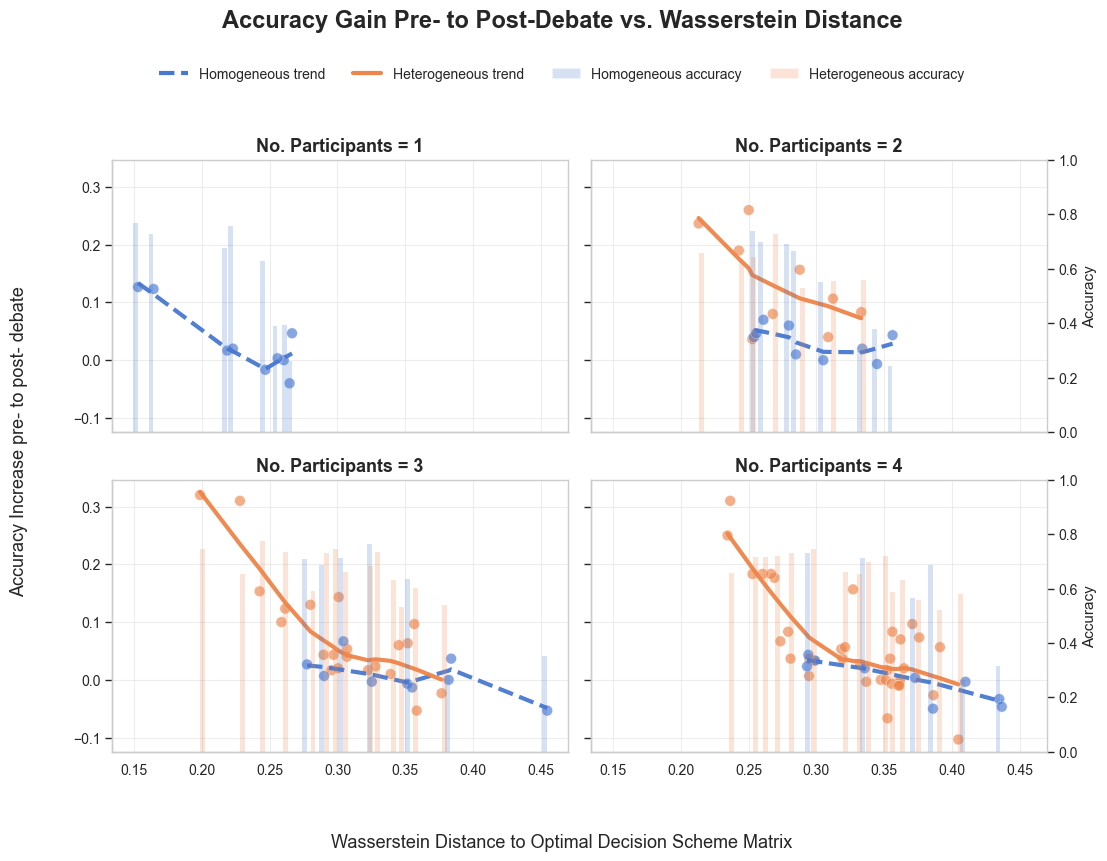

In [74]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="paper", palette="muted", font_scale=1.15)

plot_df = wd_mad.sort("group_size", "is_homogeneous").to_pandas()

plot_df["Homogeneity"] = plot_df["is_homogeneous"].map(
    {
        True: "Homogeneous",
        False: "Heterogeneous",
    }
)
plot_df["Group size"] = plot_df["group_size"].astype(int)

homogeneity_palette = {
    "Homogeneous": sns.color_palette("muted")[0],
    "Heterogeneous": sns.color_palette("muted")[1],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = 35
x_min = plot_df["wd_bias_False"].min()
x_max = plot_df["wd_bias_False"].max()
bins = np.linspace(x_min, x_max, n_bins + 1)
bin_width = bins[1] - bins[0]

bar_axes = []

for ax, group_size in zip(axes, [1, 2, 3, 4]):
    subset_g = plot_df[plot_df["Group size"] == group_size]

    # Secondary y-axis for accuracy bars
    ax_bar = ax.twinx()
    bar_axes.append(ax_bar)

    for i, (homogeneity, color) in enumerate(homogeneity_palette.items()):
        subset_h = subset_g[subset_g["Homogeneity"] == homogeneity].copy()

        if subset_h.empty:
            continue

        subset_h["wd_bin"] = pd.cut(
            subset_h["wd_bias_False"],
            bins=bins,
            include_lowest=True,
        )

        bar_df = (
            subset_h.groupby("wd_bin", observed=True)
            .agg(
                accuracy=("accuracy", "mean"),
                x=("wd_bias_False", "mean"),
            )
            .dropna()
            .reset_index()
        )

        offset = (-0.22 if homogeneity == "Homogeneous" else 0.22) * bin_width

        ax_bar.bar(
            bar_df["x"] + offset,
            bar_df["accuracy"],
            width=0.42 * bin_width,
            color=color,
            alpha=0.22,
            edgecolor="none",
            zorder=0,
        )

    ax_bar.set_ylim(0, 1)
    ax_bar.grid(False)
    ax_bar.set_ylabel("")

    # Only right column gets secondary y-label/ticks
    if group_size in [2, 4]:
        ax_bar.set_ylabel("Accuracy", fontsize=11)
    else:
        ax_bar.set_yticklabels([])
        ax_bar.tick_params(axis="y", length=0)

    # Scatter
    sns.scatterplot(
        data=subset_g,
        x="wd_bias_False",
        y="accuracy_increase",
        hue="Homogeneity",
        palette=homogeneity_palette,
        alpha=0.65,
        s=60,
        edgecolor="white",
        linewidth=0.4,
        legend=False,
        ax=ax,
        zorder=3,
    )

    # LOWESS trend lines
    for homogeneity, linestyle in [
        ("Homogeneous", "--"),
        ("Heterogeneous", "-"),
    ]:
        subset = subset_g[subset_g["Homogeneity"] == homogeneity]

        if len(subset) < 5:
            continue

        sns.regplot(
            data=subset,
            x="wd_bias_False",
            y="accuracy_increase",
            scatter=False,
            lowess=True,
            color=homogeneity_palette[homogeneity],
            ci=95,
            line_kws={
                "linewidth": 3,
                "linestyle": linestyle,
                "alpha": 0.95,
                "zorder": 4,
            },
            ax=ax,
        )

    ax.set_title(f"No. Participants = {group_size}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supxlabel(
    "Wasserstein Distance to Optimal Decision Scheme Matrix",
    fontsize=13,
    y=0.045,
)

fig.supylabel(
    "Accuracy Increase pre- to post- debate",
    fontsize=13,
    x=0.04,
)

fig.suptitle(
    "Accuracy Gain Pre- to Post-Debate vs. Wasserstein Distance",
    fontsize=17,
    fontweight="bold",
    y=0.98,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=homogeneity_palette["Homogeneous"],
        lw=3,
        linestyle="--",
        label="Homogeneous trend",
    ),
    Line2D(
        [0],
        [0],
        color=homogeneity_palette["Heterogeneous"],
        lw=3,
        linestyle="-",
        label="Heterogeneous trend",
    ),
    Patch(
        facecolor=homogeneity_palette["Homogeneous"],
        alpha=0.22,
        label="Homogeneous accuracy",
    ),
    Patch(
        facecolor=homogeneity_palette["Heterogeneous"],
        alpha=0.22,
        label="Heterogeneous accuracy",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0.05, 0.07, 0.96, 0.90])


register_materialization(
    "accuracy_gain_vs_wasserstein_distance",
    fig,
    "Wasserstein Distance vs. Accuracy and Accuracy Increase  for different number of participants",
    force=True,
)